### Analysis of Probability Distribution Priors from ResStock

heating_setpoint: 22.0,

cooling_setpoint: 26.6,

people_per_area: 3.0,

infil_flow_rate_living: 0.01,

infil_flow_rate_garage: 0.05,

infil_flow_rate_attic: 0.05,

watts_equip: 500, Can't find this

watts_lights: 1000, Can't find this

heating_COP: 4.0,

fan_efficiency: 0.7,

pressure_rise: 400.0,

solar_transmittance: 0.837,

burner_eff: 0.8,

vent_flow_rate: 0.131944

Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import gaussian_kde, gamma, norm


Configurations

In [2]:
resstock_dir = "/jumbo/keller-lab/Jeremy_Wang/resstock"
housing_characteristics_dir = os.path.join(resstock_dir, "project_national", "housing_characteristics")
options_dir = os.path.join(resstock_dir, "resources", "options_lookup.tsv")

Reading Options File

In [3]:
# Read all lines manually, pad short rows with NaN
with open(options_dir, 'r') as f:
    lines = [line.strip().split('\t') for line in f]

header = lines[0]
max_cols = max(len(row) for row in lines[1:])

# Pad header if it's shorter than some rows
while len(header) < max_cols:
    header.append(f'col_{len(header)}')

# Pad each row with None (becomes NaN in DataFrame)
padded = [row + [None] * (max_cols - len(row)) for row in lines[1:]]

options = pd.DataFrame(padded, columns=header)

List of all TSV Files Available

In [4]:
tsv_files = [f for f in os.listdir(housing_characteristics_dir) if f.endswith('.tsv')]

Function for extracting and cleaning TSV Files

In [5]:
def extract_and_clean (filename):
    df = pd.read_csv(os.path.join(housing_characteristics_dir, filename), sep='\t')

    # removing missing columns
    dep_cols = [c for c in df.columns if c.startswith("Dependency=")]
    filtered = df[
        (~df[dep_cols].eq("Not Available").any(axis=1)) &
        (df[dep_cols].notna().all(axis=1))
    ]
    return filtered


#### Heating setpoint 

In [6]:
# reading heating_setpoint file
heating_setpoint = extract_and_clean("Heating Setpoint.tsv")

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_heating_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (heating_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (heating_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (heating_setpoint['Dependency=HVAC Heating Type'] == HVAC_heating_type) # &
    # (heating_setpoint['Dependency=HVAC Has Zonal Electric Heating'] == 'No')
    )

heating_filtered = heating_setpoint[mask]

# delete misinputted dataset
heating_filtered = heating_filtered[heating_filtered['Dependency=Tenure'] != 'Not Available']

# Get option columns
opt_cols = [c for c in heating_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
heating_weights = heating_filtered['source_weight'].values
heating_weights = heating_weights / heating_weights.sum()

# Weighted average across tenure types
heating_weighted_probs = pd.Series(
    np.average(heating_filtered[opt_cols].values, axis=0, weights=heating_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
heating_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
heating_c_values = f_to_c(heating_f_values)

heating_prior = pd.DataFrame()
heating_prior["Temp"] = heating_c_values
heating_prior["Prob"] = heating_weighted_probs.values

### Using Continuous Distributions to Fit Data

In [19]:
heating_prior.columns[0]

'Temp'

In [15]:
# fits data and for KDE, gamma, and returns fit
def fit_data(prior):
    # load data
    x = prior.iloc[:, 0].values
    w = prior.iloc[:, 1].values
    # normalize weights
    w = w / w.sum()

    ### KDE
    kde = gaussian_kde(x, weights=w)

    # scale KDE to match probability bars
    dx = np.mean(np.diff(np.sort(x)))

    xs_KDE = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_KDE = kde(xs_KDE)
    ys_KDE_scaled = ys_KDE * dx

    ### Gamma distribution fit
    samples = np.random.choice(x, size=10000, p=w)
    shape, loc_g, scale_g = gamma.fit(samples, floc=0)

    xs_gamma = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_gamma = gamma.pdf(xs_gamma, shape, loc=loc_g, scale=scale_g)
    ys_gamma_scaled = ys_gamma * dx

    ### Plotting

    plt.figure(figsize=(8, 5))

    # discrete probabilities
    plt.bar(
        x,
        w,
        width=dx/3,
        alpha=0.4,
        label="Discrete probabilities"
    )

    # KDE
    plt.plot(xs_KDE, ys_KDE_scaled, linewidth=2, label="Weighted KDE")

    # Gamma fit
    plt.plot(xs_gamma, ys_gamma_scaled, linewidth=2, label="Gamma fit")

    # # KDE
    # plt.plot(xs_KDE, ys_KDE, linewidth=2, label="Weighted KDE")

    # # Gamma fit
    # plt.plot(xs_gamma, ys_gamma, linewidth=2, label="Gamma fit")

    plt.xlabel(prior.columns[0])
    plt.ylabel("Density / Probability")
    plt.title("Distribution Fit Comparison")
    plt.legend()
    plt.show()

    return 



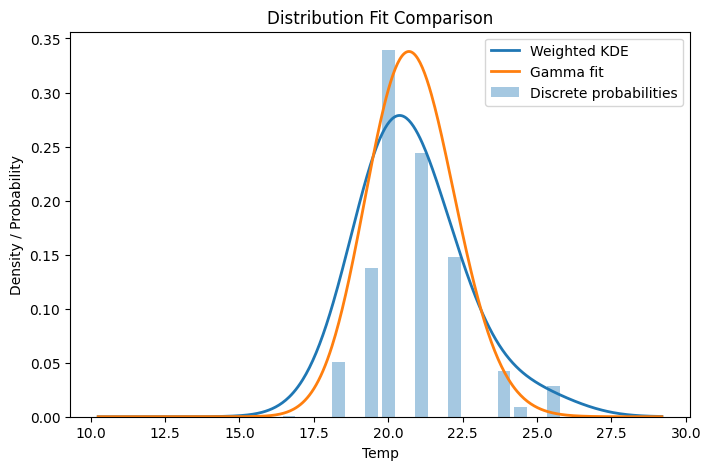

In [21]:
fit_data(heating_prior)

### Cooling Setpoint

In [16]:
# reading cooling_setpoint file
cooling_setpoint = extract_and_clean("Cooling Setpoint.tsv")

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_cooling_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (cooling_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (cooling_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (cooling_setpoint['Dependency=HVAC Cooling Type'] == HVAC_cooling_type)
    )
cooling_filtered = cooling_setpoint[mask]
cooling_filtered = cooling_filtered[cooling_filtered['Dependency=Tenure'] != 'Not Available']
cooling_filtered = cooling_filtered.drop(columns=['Option=Void'], errors='ignore')

# Get option columns
opt_cols = [c for c in cooling_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
cooling_weights = cooling_filtered['source_weight'].values
cooling_weights = cooling_weights / cooling_weights.sum()
# Weighted average across tenure types
cooling_weighted_probs = pd.Series(
    np.average(cooling_filtered[opt_cols].values, axis=0, weights=cooling_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
cooling_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
cooling_c_values = f_to_c(cooling_f_values)

cooling_prior = pd.DataFrame()
cooling_prior["Temp"] = cooling_c_values
cooling_prior["Prob"] = cooling_weighted_probs.values

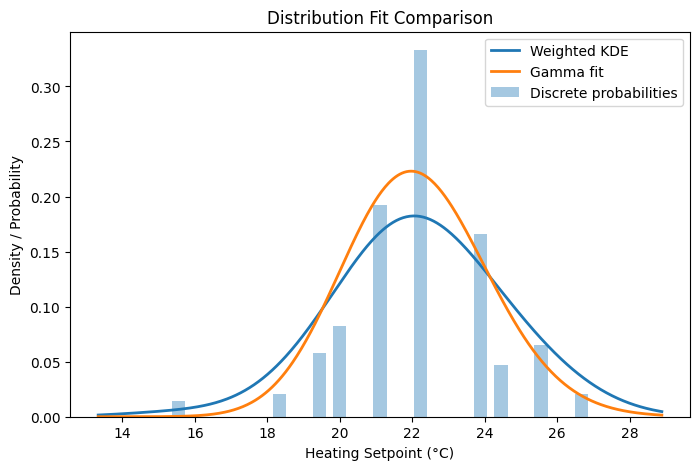

In [76]:
fit_data(cooling_prior)

Plot of Heating and Cooling PDFs

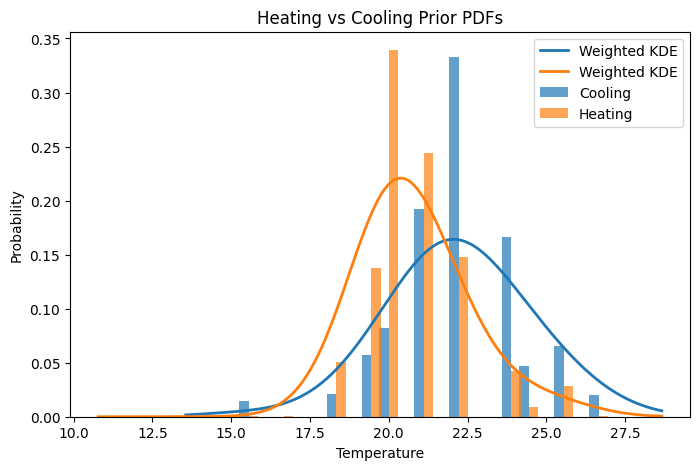

In [20]:
width = 0.3  # bar width

plt.figure(figsize=(8,5))

# Cooling
plt.bar(
    cooling_prior['Temp'] - width/2,
    cooling_prior['Prob'],
    width=width,
    label='Cooling',
    alpha=0.7
)

# KDE curve on top
plt.plot(
    xs_cooling,
    ys_cooling,
    linewidth=2,
    label='Weighted KDE'
)

# Heating
plt.bar(
    heating_prior['Temp'] + width/2,
    heating_prior['Prob'],
    width=width,
    label='Heating',
    alpha=0.7
)

plt.plot(
    xs_heating,
    ys_heating,
    linewidth=2,
    label='Weighted KDE'
)

plt.xlabel("Temperature")
plt.ylabel("Probability")
plt.title("Heating vs Cooling Prior PDFs")
plt.legend()

plt.show()

#### People

In [22]:
# reading file
people_filtered = extract_and_clean("Occupants.tsv")

# IDF constraints
building_type = "Single-Family Detached" 
census_division = "East North Central"
bedrooms = "3" # assume 3 bedrooms because IDF specifies that number of occupants

# Note: Not controlling for income, metro status, or tenure status

# mask
mask = (
    (people_filtered['Dependency=Geometry Building Type RECS'] == building_type) &
    (people_filtered['Dependency=Census Division'] == census_division) & 
    (people_filtered['Dependency=Bedrooms'] == bedrooms)
)

people_filtered = people_filtered[mask]

# Get option columns
opt_cols = [c for c in people_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
people_weights = people_filtered['source_weight'].values
people_weights = people_weights / people_weights.sum()

# Weighted average across dependency types
people_weighted_probs = pd.Series(
    np.average(people_filtered[opt_cols].values, axis=0, weights=people_weights),
    index=opt_cols
)

people_values = np.array([
    float(c.replace("Option=", "").replace("+", ""))  # remove 'Option=' and '+'
    for c in opt_cols
])

people_prior = pd.DataFrame()
people_prior["People"] = people_values
people_prior["Prob"] = people_weighted_probs.values

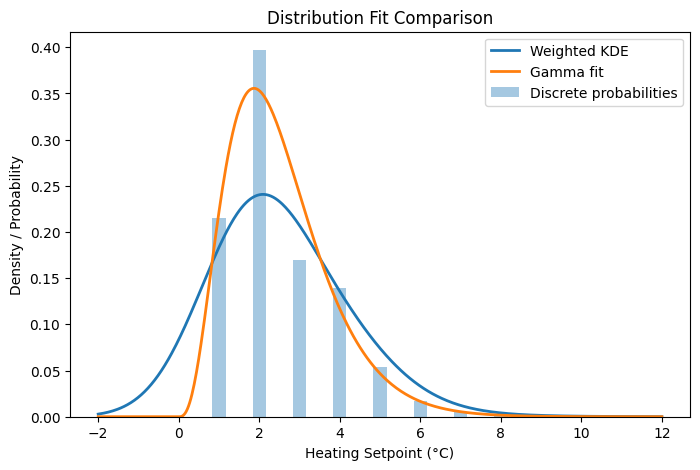

In [79]:
fit_data(people_prior)

#### Infiltration Rate

Assumptions:
Living Zone, Garage Zone, Attic Zone all use the same infiltration rate

CC (Conversion Coefficient) between ACH50 to ACH = 22.2

Floor Area = 186 m^2

Height = 3 m

In [16]:
infil_filtered = extract_and_clean("Infiltration.tsv")

# IDF Constraints
climate_zone = "5A" # Chicago  
floor_area = ["1500-1999","2000-2499"] # consider floor areas ranging from 1500 - 2499 ft^2

mask = (
    (infil_filtered['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    ((infil_filtered['Dependency=Geometry Floor Area'] == floor_area[0]) | (infil_filtered['Dependency=Geometry Floor Area'] == floor_area[1]))
)

infil_filtered = infil_filtered[mask]

opt_cols = [c for c in infil_filtered.columns if c.startswith("Option=")]

# weight by sampling probability
infil_probs = pd.Series(
    np.average(
        infil_filtered[opt_cols].values,
        axis=0,
        weights=infil_filtered["sampling_probability"]
    ),
    index=opt_cols
)

# unit conversations 
CC = 22.2 # conversion coefficient
FA = 186 # Floor Area m^2
H = 3 # Height  m 

ACH50_values = np.array([float(c.replace('Option=', '').replace('ACH50', '')) 
                     for c in opt_cols])

Q_values = (ACH50_values * (FA * H))/(3600*CC) # converting into m^3/s

infil_prior = pd.DataFrame()
infil_prior["Q"] = Q_values
infil_prior["Prob"] = infil_probs.values


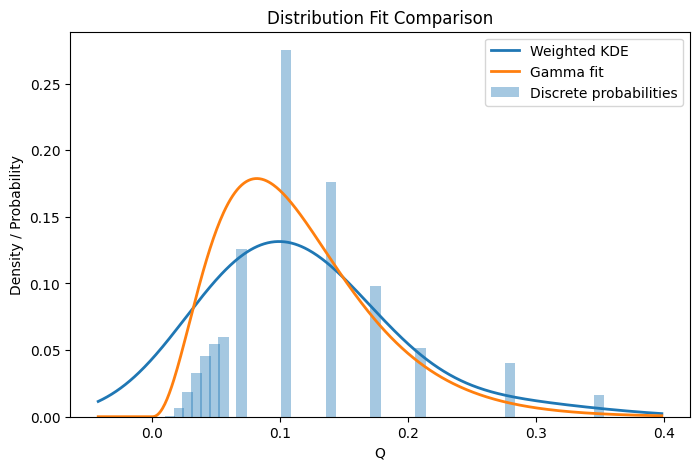

In [17]:
fit_data(infil_prior)

#### Equipment Watts

Can't find baseline value, and distribution is a singular point

In [43]:
# use TSV file titled "plug loads"
equip_filtered = extract_and_clean("Plug Loads.tsv")
# IDF constraints
census_division = "East North Central"
building_type = "Single-Family Detached"

mask = (
    (equip_filtered['Dependency=Census Division RECS'] == census_division) &
    (equip_filtered['Dependency=Geometry Building Type RECS'] == building_type)
)

equip_filtered = equip_filtered[mask]

#### Lighting Watts

Options are quantitatively describing the type of lights being used

Need Lookup table

In [44]:
lighting = extract_and_clean("Lighting.tsv")

# constraints
state = "IL"
building_type = "Single-Family Detached"

mask = (
    (lighting['Dependency=State'] == state) & 
    (lighting['Dependency=Geometry Building Type RECS'] == building_type)
)

lighting = lighting[mask]


#### Heating COP

No values can be found with the given dependencies

In [17]:
heating_COP_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Electricity"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (heating_COP_filtered['Dependency=Custom State'] == State) &
    (heating_COP_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (heating_COP_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

heating_COP_filtered = heating_COP_filtered[mask]


#### Fan Efficiency

Unable to be sourced

#### Pressure Rise

Not found

#### Solar Transmittance

Options are quantitatively describing the type of window used

Need lookup table

In [6]:
solar_transmittance = extract_and_clean("Windows.tsv")

# constraints
climate_zone = "5A"
building_type = "Single-Family Detached"

mask = (
    (solar_transmittance['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (solar_transmittance['Dependency=Geometry Building Type RECS'] == building_type)  # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

solar_transmittance = solar_transmittance[mask]

# Get option columns
opt_cols = [c for c in solar_transmittance.columns if c.startswith('Option=')]

# Weight by source_weight
solar_weights = solar_transmittance['source_weight'].values
solar_weights = solar_weights / solar_weights.sum()

# Weighted average across dependency types
solar_weighted_probs = pd.Series(
    np.average(solar_transmittance[opt_cols].values, axis=0, weights=solar_weights),
    index=opt_cols
)

In [14]:
solar_weighted_probs.index


Index(['Option=Double, Clear, Metal, Air',
       'Option=Double, Clear, Metal, Air, Exterior Clear Storm',
       'Option=Double, Clear, Non-metal, Air',
       'Option=Double, Clear, Non-metal, Air, Exterior Clear Storm',
       'Option=Double, Low-E, Non-metal, Air, M-Gain',
       'Option=Single, Clear, Metal',
       'Option=Single, Clear, Metal, Exterior Clear Storm',
       'Option=Single, Clear, Non-metal',
       'Option=Single, Clear, Non-metal, Exterior Clear Storm',
       'Option=Triple, Low-E, Non-metal, Air, L-Gain', 'Option=Void'],
      dtype='object')

#### Burner Efficiency

No values can be found with the given dependencies

In [20]:
burner_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Natural Gas"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (burner_filtered['Dependency=Custom State'] == State) &
    (burner_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (burner_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

burner_filtered = burner_filtered[mask]

# Issue arises with no distribution available


In [21]:
burner_filtered

,Dependency=Custom State,Dependency=Heating Fuel,Dependency=HVAC Has Shared System,Dependency=HVAC Heating Type,Dependency=Vintage,"Option=ASHP, SEER2 9.5, 5.8 HSPF2","Option=ASHP, SEER2 12.4, 6.6 HSPF2","Option=ASHP, SEER2 14.3, 7.4 HSPF2","Option=Electric Baseboard, 100% Efficiency","Option=Electric Boiler, 100% AFUE",...,"Option=Fuel Wall/Floor Furnace, 60% AFUE","Option=Fuel Wall/Floor Furnace, 68% AFUE","Option=MSHP, SEER2 13.7, 7.4 HSPF2","Option=MSHP, SEER2 29, 12.3 HSPF2",Option=None,Option=Shared Heating,Option=Void,source_count,source_weight,sampling_probability
360,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1940s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
361,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1950s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
362,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1960s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
363,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1970s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
364,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1980s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
365,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1990s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
366,Others,Natural Gas,Cooling Only,Ducted Heat Pump,2000s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
367,Others,Natural Gas,Cooling Only,Ducted Heat Pump,2010s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
368,Others,Natural Gas,Cooling Only,Ducted Heat Pump,<1940,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
369,Others,Natural Gas,Heating Only,Ducted Heat Pump,1940s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Ventilation Flow Rate

Can't find parameter values

### plots

Weighted mean: 20.80C
Weighted std:  1.52C


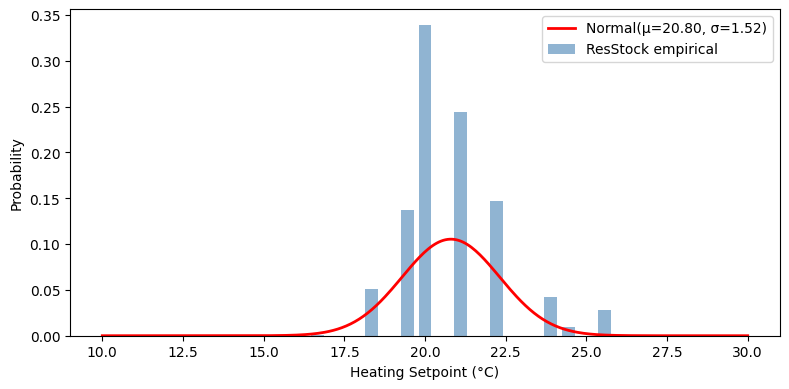


Concrete prior: Normal(mean=20.80, std=1.52)
Weighted mean: 22.18C
Weighted std:  1.97C


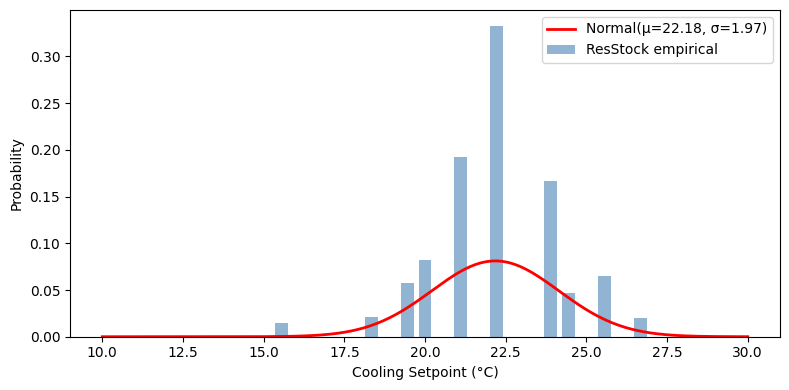


Concrete prior: Normal(mean=22.18, std=1.97)


In [22]:

# Compute weighted mean and std directly from the distribution
def plot_setpoint_prior (c_values, weighted_probs, title):
        mean_c = np.average(c_values, weights=weighted_probs.values)
        std_c = np.sqrt(np.average((c_values - mean_c)**2, weights=weighted_probs.values))

        print(f"Weighted mean: {mean_c:.2f}C")
        print(f"Weighted std:  {std_c:.2f}C")

        x = np.linspace(10, 30, 300)
        normal_pdf = stats.norm.pdf(x, loc=mean_c, scale=std_c)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(c_values, weighted_probs.values, width=0.4, alpha=0.6,
        label='ResStock empirical', color='steelblue')
        ax.plot(x, normal_pdf * 0.4, 'r-', lw=2,
                label=f'Normal(μ={mean_c:.2f}, σ={std_c:.2f})')
        ax.set_xlabel(f'{title} (°C)')
        ax.set_ylabel('Probability')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"\nConcrete prior: Normal(mean={mean_c:.2f}, std={std_c:.2f})")

plot_setpoint_prior(heating_c_values, heating_weighted_probs, "Heating Setpoint")
plot_setpoint_prior(cooling_c_values, cooling_weighted_probs, "Cooling Setpoint")